# 06_AugLy_MultiModal_Augmentation

This notebook demonstrates **multi-modal data augmentation** with **AugLy** and **nlpaug** in Google Colab.

## What this notebook covers
- **Image augmentation** with AugLy
- **Text augmentation** with nlpaug
- **Audio augmentation** with AugLy
- **Video augmentation** with AugLy
- A small **metadata / robustness** section to inspect what each transform did

## Why this notebook exists
Some Colab runtimes hit the Pillow / `PIL._util` import problem after package installation.  
To avoid that, this notebook uses:
1. a **clean setup cell**
2. a **one-time restart step**
3. pinned package installation before any AugLy imports


## How to run this notebook

1. Run the **setup cell** below.
2. If the cell says **restart runtime**, do that once.
3. After restart, run the notebook top to bottom.

This pattern avoids the mixed-library state that can trigger:
`ImportError: cannot import name 'is_directory' from 'PIL._util'`


In [1]:
# =========================
# One-time setup for Colab
# =========================
import os
import sys
import subprocess
from pathlib import Path

SENTINEL = "/content/.augly_multimodal_setup_v5"

if not os.path.exists(SENTINEL):
    print("Fresh setup: installing compatible packages for AugLy in Colab...")

    commands = [
        [sys.executable, "-m", "pip", "uninstall", "-y", "augly", "torch", "torchaudio", "torchvision", "Pillow", "scikit-image"],
        [sys.executable, "-m", "pip", "install", "-q", "--upgrade", "pip", "setuptools", "wheel"],
        ["apt-get", "-qq", "update"],
        ["apt-get", "-qq", "install", "-y", "ffmpeg", "libsndfile1", "libmagic1", "sox"],
        [sys.executable, "-m", "pip", "install", "-q",
         "Pillow>=10.1,<12", "numpy<2.0", "matplotlib", "pandas", "nltk",
         "python-magic", "opencv-python-headless", "imageio", "imageio-ffmpeg",
         "av", "audioread", "librosa", "soundfile", "nlpaug", "iopath"],
        [sys.executable, "-m", "pip", "install", "-q",
         "torch==2.4.1", "torchvision==0.19.1", "torchaudio==2.4.1",
         "--index-url", "https://download.pytorch.org/whl/cpu"],
        [sys.executable, "-m", "pip", "install", "-q", "augly==1.0.0", "--no-deps"],
    ]

    for cmd in commands:
        print("Running:", " ".join(cmd))
        subprocess.check_call(cmd)

    Path(SENTINEL).write_text("ok")
    raise SystemExit(
        "Setup finished successfully. Please go to Runtime -> Restart session, "
        "then run this setup cell one more time and continue with the notebook."
    )
else:
    print("Setup already completed for this runtime image. You can continue below.")


Setup already completed for this runtime image. You can continue below.


In [2]:
# =========================
# Imports + version check
# =========================
!pip install -q ffmpeg-python
!pip install -q vidgear

from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import imageio.v2 as imageio

from PIL import Image, ImageDraw
from IPython.display import Audio, Video, display, Markdown

import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

import torch
import torchaudio
from torchaudio import sox_effects

import iopath
import augly.image as imaugs
import augly.audio as audaugs
import augly.video as vidaugs
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.char as nac

WORKDIR = Path("/content/augly_demo")
WORKDIR.mkdir(parents=True, exist_ok=True)

print("torch:", torch.__version__)
print("torchaudio:", torchaudio.__version__)
print("Pillow:", Image.__version__)
print("iopath:", getattr(iopath, "__version__", "installed"))
print("sox_effects available:", hasattr(sox_effects, "apply_effects_tensor"))
print("Working directory:", WORKDIR)


torch: 2.4.1+cpu
torchaudio: 2.4.1+cpu
Pillow: 11.3.0
iopath: 0.1.10
sox_effects available: True
Working directory: /content/augly_demo


## Helper functions

The next cell creates synthetic demo data so the notebook does **not** depend on external downloads for sample image, audio, or video content.


In [3]:
# =========================
# Helper functions
# =========================
def make_demo_image(path: Path, size=(256, 256)):
    img = Image.new("RGB", size, color=(245, 248, 252))
    draw = ImageDraw.Draw(img)

    # sky
    draw.rectangle([0, 0, size[0], 140], fill=(190, 225, 255))
    # grass
    draw.rectangle([0, 140, size[0], size[1]], fill=(170, 215, 140))
    # sun
    draw.ellipse([180, 20, 235, 75], fill=(255, 213, 90))
    # house
    draw.rectangle([70, 110, 170, 210], fill=(230, 160, 120), outline=(80, 60, 40), width=3)
    draw.polygon([(60, 110), (120, 65), (180, 110)], fill=(120, 75, 65), outline=(80, 50, 40))
    draw.rectangle([105, 155, 135, 210], fill=(95, 65, 50))
    draw.rectangle([82, 130, 105, 153], fill=(210, 240, 255))
    draw.rectangle([135, 130, 158, 153], fill=(210, 240, 255))
    # path
    draw.polygon([(110, 210), (135, 210), (160, 256), (85, 256)], fill=(205, 190, 165))
    # text label
    draw.text((14, 14), "AugLy Demo Scene", fill=(25, 25, 25))

    img.save(path)
    return path

def show_pil_grid(images_dict, cols=3, figsize=(14, 10)):
    items = list(images_dict.items())
    rows = math.ceil(len(items) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (title, image_obj) in zip(axes, items):
        ax.imshow(np.array(image_obj))
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

def make_demo_audio(path: Path, sr=16000, seconds=2.5):
    t = np.linspace(0, seconds, int(sr * seconds), endpoint=False)
    wave = (
        0.45 * np.sin(2 * np.pi * 440 * t) +
        0.20 * np.sin(2 * np.pi * 660 * t) +
        0.08 * np.sin(2 * np.pi * 880 * t)
    ).astype(np.float32)
    sf.write(path, wave, sr)
    return path, sr

def plot_waveform(audio, sr, title):
    time_axis = np.arange(len(audio)) / sr
    plt.figure(figsize=(12, 3))
    plt.plot(time_axis, audio)
    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

def make_demo_video(path: Path, n_frames=24, size=(192, 192), fps=8):
    frames = []
    w, h = size
    for i in range(n_frames):
        img = Image.new("RGB", size, color=(240, 243, 248))
        draw = ImageDraw.Draw(img)
        x = 20 + i * 5
        y = 80 + int(18 * math.sin(i / 3))
        draw.rectangle([0, 120, w, h], fill=(180, 220, 170))
        draw.ellipse([x, y, x + 38, y + 38], fill=(70, 130, 255))
        draw.text((10, 10), f"frame={i:02d}", fill=(30, 30, 30))
        frames.append(np.array(img))
    imageio.mimwrite(path, frames, fps=fps, codec="libx264")
    return path

base_image_path = make_demo_image(WORKDIR / "base_image.png")
base_audio_path, base_sr = make_demo_audio(WORKDIR / "base_audio.wav")
base_video_path = make_demo_video(WORKDIR / "base_video.mp4")

print("Created:")
print("-", base_image_path)
print("-", base_audio_path)
print("-", base_video_path)


Created:
- /content/augly_demo/base_image.png
- /content/augly_demo/base_audio.wav
- /content/augly_demo/base_video.mp4


## 1) Image augmentation with AugLy

We will apply several image transforms:
- rotate
- horizontal flip
- grayscale
- random noise
- color jitter
- pad to square
- emoji overlay


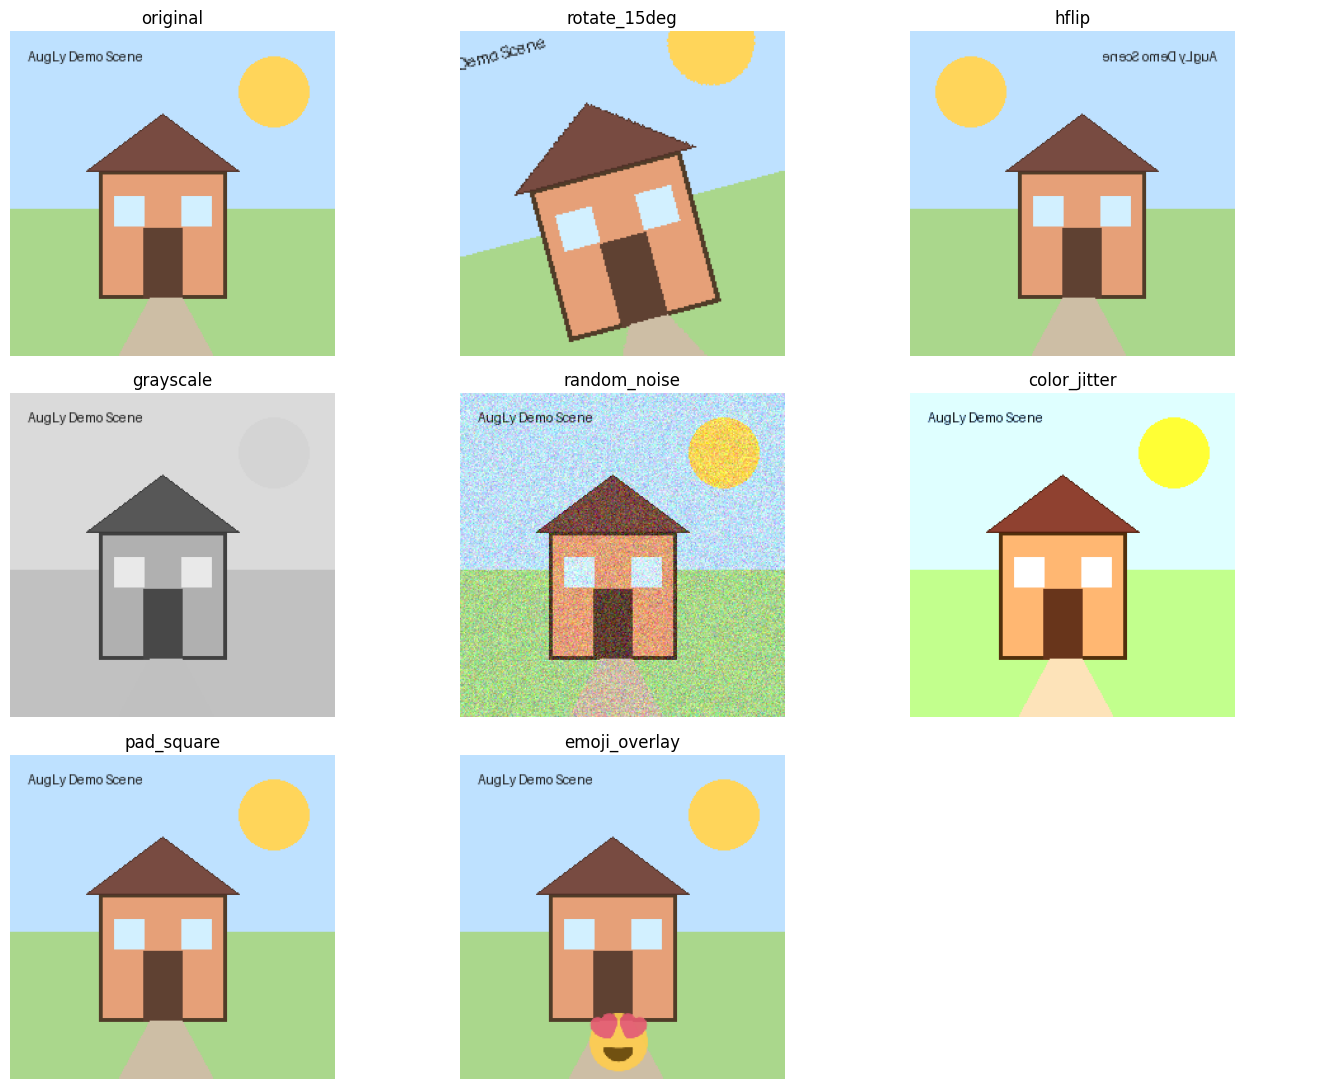

In [4]:
# =========================
# Image augmentation
# =========================
base_image = Image.open(base_image_path)

image_versions = {
    "original": base_image,
    "rotate_15deg": imaugs.rotate(base_image, degrees=15),
    "hflip": imaugs.hflip(base_image),
    "grayscale": imaugs.grayscale(base_image),
    "random_noise": imaugs.random_noise(base_image),
    "color_jitter": imaugs.color_jitter(base_image, brightness_factor=1.2, contrast_factor=1.15, saturation_factor=1.25),
    "pad_square": imaugs.pad_square(base_image),
    "emoji_overlay": imaugs.overlay_emoji(base_image, opacity=0.9, emoji_size=0.18),
}

show_pil_grid(image_versions, cols=3, figsize=(14, 11))


In [5]:
# Metadata example for one image transform
meta = []
_ = imaugs.rotate(base_image, degrees=12, metadata=meta)
pd.DataFrame(meta)


,name,src_width,src_height,dst_width,dst_height,output_path,degrees,bbox_format,intensity
0,rotate,256,256,215,215,None,12,None,6.666667


## 2) Text augmentation with nlpaug

This section uses `nlpaug` because it is lightweight and works well for demonstration in Colab.

We will generate:
- synonym replacement
- keyboard noise
- random word swap


In [6]:
# =========================
# Text augmentation
# =========================
sample_text = (
    "Deep learning models can become more robust when training data is augmented carefully."
)

text_augmenters = {
    "original": None,
    "synonym_aug": naw.SynonymAug(aug_src="wordnet"),
    "keyboard_aug": nac.KeyboardAug(aug_char_p=0.25),
    "random_swap": naw.RandomWordAug(action="swap", aug_p=0.3),
}

text_rows = [{"augmentation": "original", "output": sample_text}]
for name, augmenter in text_augmenters.items():
    if augmenter is None:
        continue
    augmented = augmenter.augment(sample_text)
    if isinstance(augmented, list):
        augmented = augmented[0]
    text_rows.append({"augmentation": name, "output": augmented})

pd.DataFrame(text_rows)


,augmentation,output
0,original,Deep learning models can become more robust wh...
1,synonym_aug,Deep learning models can go more robust when t...
2,keyboard_aug,Deep learning models can FeVome mLre robust wh...
3,random_swap,Deep learning models can more become training ...


## 3) Audio augmentation with AugLy

We will create a synthetic waveform, then apply:
- volume change
- pitch shift
- time stretch
- clicks

You can listen to the original and augmented outputs directly in Colab.


### Install `sox` system library directly

This cell will install the `sox` system library, which is required by `torchaudio` for audio augmentations. This is an alternative to restarting the runtime and re-running the setup cell.

In [7]:
import subprocess

print("Installing sox and libsox-dev system libraries...")
subprocess.check_call(["apt-get", "-qq", "update"])
subprocess.check_call(["apt-get", "-qq", "install", "-y", "sox", "libsox-dev"])
print("sox and libsox-dev installed. Please restart the runtime and re-run all cells.")


Installing sox and libsox-dev system libraries...
sox and libsox-dev installed. Please restart the runtime and re-run all cells.


### original

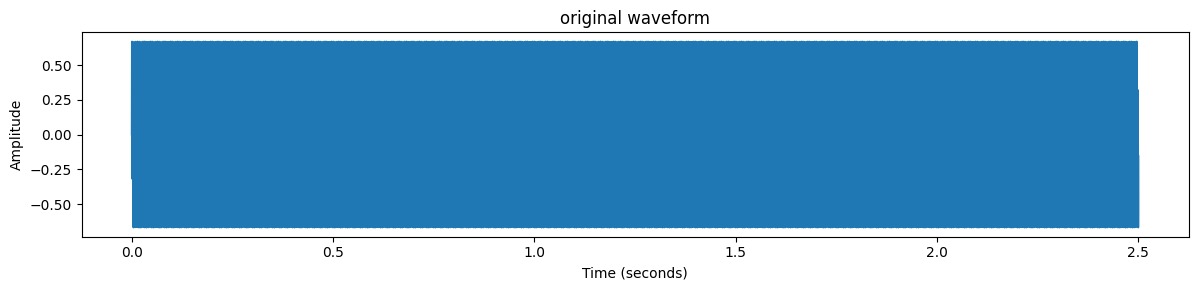

### louder

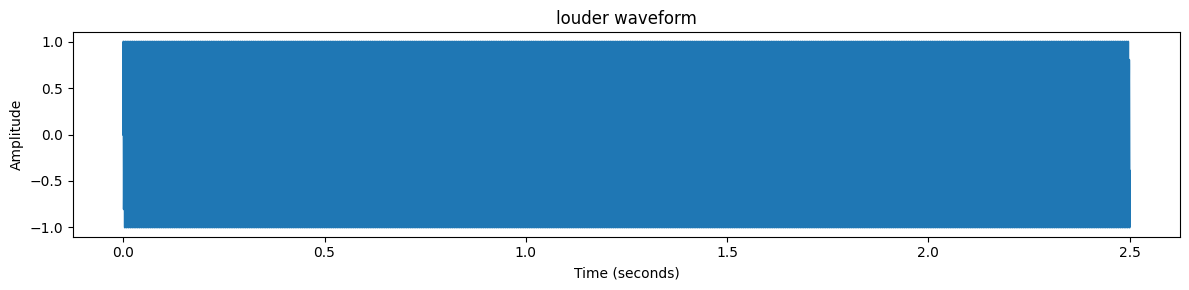

### pitch_up

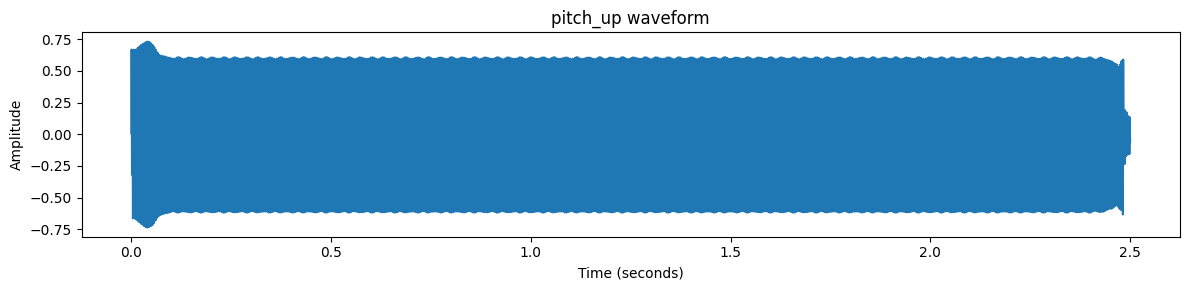

### time_stretch

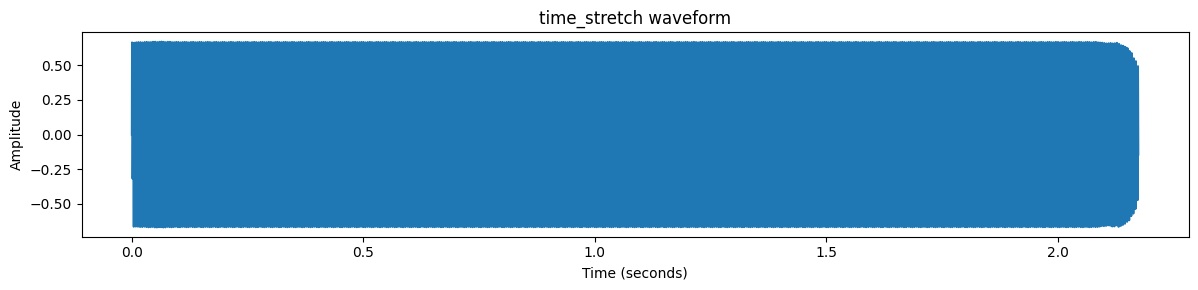

### clicks

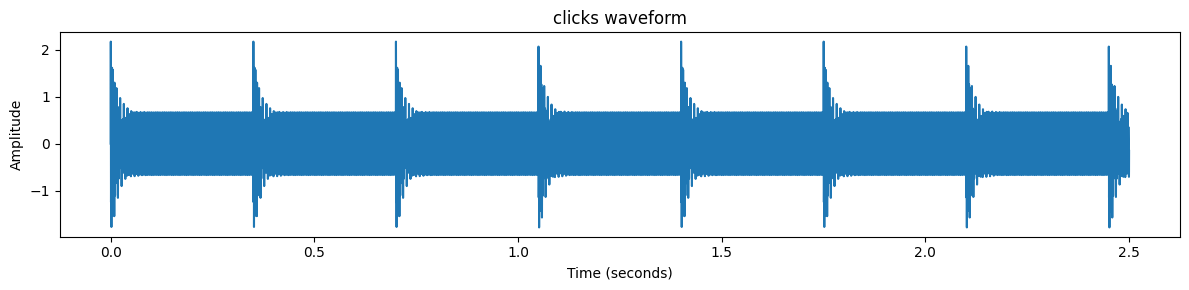

In [8]:
# =========================
# Audio augmentation
# =========================
base_audio, sr = sf.read(base_audio_path)

audio_versions = {"original": (base_audio, sr)}

audio_versions["louder"] = audaugs.change_volume(base_audio, sample_rate=sr, volume_db=8.0)
audio_versions["pitch_up"] = audaugs.pitch_shift(base_audio, sample_rate=sr, n_steps=2.0)
audio_versions["time_stretch"] = audaugs.time_stretch(base_audio, sample_rate=sr, rate=1.15)
audio_versions["clicks"] = audaugs.clicks(base_audio, sample_rate=sr, seconds_between_clicks=0.35, snr_level_db=6.0)

for name, (audio_arr, audio_sr) in audio_versions.items():
    display(Markdown(f"### {name}"))
    plot_waveform(audio_arr, audio_sr, f"{name} waveform")
    display(Audio(audio_arr, rate=audio_sr))

## 4) Video augmentation with AugLy

For video we create a tiny synthetic clip and save augmented versions to disk.

Transforms used here:
- horizontal flip
- grayscale
- noise
- speed change


In [10]:
# =========================
# Video augmentation
# =========================
# Monkey-patch to fix vidgear compatibility issue with AugLy
import vidgear.gears.writegear
_orig_init = vidgear.gears.writegear.WriteGear.__init__
def _patched_init(self, *args, **kwargs):
    if "output_filename" in kwargs:
        kwargs["output"] = kwargs.pop("output_filename")
    _orig_init(self, *args, **kwargs)
vidgear.gears.writegear.WriteGear.__init__ = _patched_init

video_outputs = {
    "original": str(base_video_path),
    "hflip": str(WORKDIR / "video_hflip.mp4"),
    "grayscale": str(WORKDIR / "video_grayscale.mp4"),
    "noise": str(WORKDIR / "video_noise.mp4"),
    "speed_up": str(WORKDIR / "video_speed_up.mp4"),
}

vidaugs.hflip(str(base_video_path), output_path=video_outputs["hflip"])
vidaugs.grayscale(str(base_video_path), output_path=video_outputs["grayscale"])
vidaugs.add_noise(str(base_video_path), output_path=video_outputs["noise"], level=8)
vidaugs.change_video_speed(str(base_video_path), output_path=video_outputs["speed_up"], factor=1.35)

for name, video_path in video_outputs.items():
    display(Markdown(f"### {name}"))
    display(Video(video_path, embed=True))


21:20:18 ::   WriteGear   ::  DEBUG   :: Output Parameters: `{}`
21:20:18 ::   WriteGear   ::  DEBUG   :: Compression Mode is enabled therefore checking for valid FFmpeg executable.
21:20:18 ::   WriteGear   :: WARNING  :: Optional `-disable_ffmpeg_window` flag is only available on Windows OS with `logging=False`. Discarding!
21:20:18 ::    Helper     ::  DEBUG   :: Final FFmpeg Path: ffmpeg
21:20:18 ::    Helper     ::   INFO   :: FFmpeg validity Test Passed!
21:20:18 ::    Helper     ::  DEBUG   :: Found valid FFmpeg Version: `b'4.4.2-0ubuntu0.22.04.1'` installed on this system
21:20:18 ::   WriteGear   ::  DEBUG   :: Found valid FFmpeg executable: `ffmpeg`.
21:20:18 ::   WriteGear   ::  DEBUG   :: Compression Mode with FFmpeg backend is configured properly.
21:20:18 ::   WriteGear   ::  DEBUG   :: Executing FFmpeg command: `ffmpeg -y -i /content/augly_demo/base_video.mp4 -vf hflip -c:a copy -preset ultrafast /content/augly_demo/video_hflip.mp4`
21:20:18 ::   WriteGear   ::  DEBUG   

### original

### hflip

### grayscale

### noise

### speed_up

In [11]:
# Metadata example for video augmentation
video_meta = []
_ = vidaugs.change_video_speed(
    str(base_video_path),
    output_path=str(WORKDIR / "video_speed_with_meta.mp4"),
    factor=1.25,
    metadata=video_meta,
)
pd.DataFrame(video_meta)


21:20:46 ::   WriteGear   ::  DEBUG   :: Output Parameters: `{}`
21:20:46 ::   WriteGear   ::  DEBUG   :: Compression Mode is enabled therefore checking for valid FFmpeg executable.
21:20:46 ::   WriteGear   :: WARNING  :: Optional `-disable_ffmpeg_window` flag is only available on Windows OS with `logging=False`. Discarding!
21:20:46 ::    Helper     ::  DEBUG   :: Final FFmpeg Path: ffmpeg
21:20:46 ::    Helper     ::   INFO   :: FFmpeg validity Test Passed!
21:20:46 ::    Helper     ::  DEBUG   :: Found valid FFmpeg Version: `b'4.4.2-0ubuntu0.22.04.1'` installed on this system
21:20:46 ::   WriteGear   ::  DEBUG   :: Found valid FFmpeg executable: `ffmpeg`.
21:20:46 ::   WriteGear   ::  DEBUG   :: Compression Mode with FFmpeg backend is configured properly.
21:20:46 ::   WriteGear   ::  DEBUG   :: Executing FFmpeg command: `ffmpeg -y -i /content/augly_demo/base_video.mp4 -vf setpts=0.8*PTS -filter:a atempo=1.25 -preset ultrafast /content/augly_demo/video_speed_with_meta.mp4`
21:20:4

,name,src_duration,dst_duration,src_fps,dst_fps,src_width,src_height,dst_width,dst_height,src_segments,dst_segments,factor,intensity
0,change_video_speed,3.0,2.625,8.0,8.0,192,192,192,192,"[{'start': 0.0, 'end': 3.0}]","[{'start': 0.0, 'end': 2.625}]",1.25,12.5


## Summary

This notebook provides a cleaner replacement for the original Colab 6 by:
- keeping the **same notebook scope**
- avoiding fragile external demo assets
- pinning Pillow early
- forcing a **clean restart boundary** before AugLy imports
- demonstrating **image, text, audio, and video** augmentation in one place
